In [1]:
# ===========================
# DOWNLOAD DATASET
# ===========================

import os
import kagglehub

# Download dataset
path = kagglehub.dataset_download("andrewmvd/hard-hat-detection")

print("Dataset Path:", path)

# ===========================
# DEFINE PATHS
# ===========================

image_folder = os.path.join(path, "images")
annotation_folder = os.path.join(path, "annotations")
labels_folder = os.path.join(path, "labels")

print("\nFolders Found:")
print(os.listdir(path))

print("\nImage Folder :", image_folder)
print("Annotation Folder :", annotation_folder)
print("Labels Folder :", labels_folder)

100%|██████████| 1.22G/1.22G [00:19<00:00, 68.3MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/andrewmvd/hard-hat-detection/versions/1

Folders Found:
['annotations', 'images']

Image Folder : /root/.cache/kagglehub/datasets/andrewmvd/hard-hat-detection/versions/1/images
Annotation Folder : /root/.cache/kagglehub/datasets/andrewmvd/hard-hat-detection/versions/1/annotations
Labels Folder : /root/.cache/kagglehub/datasets/andrewmvd/hard-hat-detection/versions/1/labels


In [2]:
!pip install ultralytics -q

from ultralytics import YOLO

print("YOLO Installed Successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO Installed Successfully!


In [3]:
import xml.etree.ElementTree as ET

classes = set()

for xml_file in os.listdir(annotation_folder):
    tree = ET.parse(os.path.join(annotation_folder, xml_file))
    root = tree.getroot()

    for obj in root.findall("object"):
        classes.add(obj.find("name").text)

print("Classes:", classes)

Classes: {'head', 'person', 'helmet'}


In [4]:
import os
import xml.etree.ElementTree as ET

# Redefine labels_folder to a writable location
labels_folder = os.path.join("/kaggle/working", "labels")

os.makedirs(labels_folder, exist_ok=True)

class_map = {
    "helmet": 0,
    "head": 1,
    "person": 2
}

for xml_file in os.listdir(annotation_folder):

    tree = ET.parse(os.path.join(annotation_folder, xml_file))
    root = tree.getroot()

    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)

    txt_file = os.path.join(labels_folder, xml_file.replace(".xml", ".txt"))

    with open(txt_file, "w") as f:

        for obj in root.findall("object"):

            cls = class_map[obj.find("name").text]

            box = obj.find("bndbox")

            xmin = float(box.find("xmin").text)
            ymin = float(box.find("ymin").text)
            xmax = float(box.find("xmax").text)
            ymax = float(box.find("ymax").text)

            x = ((xmin + xmax) / 2) / width
            y = ((ymin + ymax) / 2) / height
            w = (xmax - xmin) / width
            h = (ymax - ymin) / height

            f.write(f"{cls} {x} {y} {w} {h}\n")

print("XML converted to YOLO format successfully!")

XML converted to YOLO format successfully!


In [5]:
import os
import shutil
import random

# Redefine dataset_dir to a writable location
dataset_dir = os.path.join("/kaggle/working", "dataset")

# Create folders
for folder in [
    "images/train",
    "images/val",
    "images/test",
    "labels/train",
    "labels/val",
    "labels/test"
]:
    os.makedirs(os.path.join(dataset_dir, folder), exist_ok=True)

# Read images
images = [
    f for f in os.listdir(image_folder)
    if f.endswith((".jpg", ".jpeg", ".png"))
]

random.seed(42)
random.shuffle(images)

train_end = int(len(images) * 0.8)
val_end = int(len(images) * 0.9)

train = images[:train_end]
val = images[train_end:val_end]
test = images[val_end:]

def copy_data(files, split):

    for img in files:

        label = os.path.splitext(img)[0] + ".txt"

        shutil.copy(
            os.path.join(image_folder, img),
            os.path.join(dataset_dir, "images", split, img)
        )

        shutil.copy(
            os.path.join(labels_folder, label),
            os.path.join(dataset_dir, "labels", split, label)
        )

copy_data(train, "train")
copy_data(val, "val")
copy_data(test, "test")

print("Dataset Split Completed!")

print("Train:", len(train))
print("Validation:", len(val))
print("Test:", len(test))

Dataset Split Completed!
Train: 4000
Validation: 500
Test: 500


In [6]:
import yaml
import os

# Path to the dataset folder
dataset_dir = os.path.join("/kaggle/working", "dataset")

data = {
    "path": dataset_dir,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "helmet",
        1: "head",
        2: "person"
    }
}

yaml_path = os.path.join(dataset_dir, "data.yaml")

with open(yaml_path, "w") as f:
    yaml.dump(data, f)

print("data.yaml created successfully!")
print("Saved at:", yaml_path)

data.yaml created successfully!
Saved at: /kaggle/working/dataset/data.yaml


In [7]:
with open(yaml_path, "r") as f:
    print(f.read())

names:
  0: helmet
  1: head
  2: person
path: /kaggle/working/dataset
test: images/test
train: images/train
val: images/val



In [16]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data=yaml_path,
    epochs=5,
    imgsz=320,
    batch=4,
    workers=2,
    project="HardHatDetection",
    name="yolo11n_fast",
    pretrained=True
)

Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_fast-2, nbs=64, nms=F

In [11]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/HardHatDetection/yolo11n_fast/weights/best.pt")

results = model.predict(
    source=os.path.join(image_folder, os.listdir(image_folder)[0]),
    save=True,
    conf=0.25
)

print("Prediction completed!")


image 1/1 /root/.cache/kagglehub/datasets/andrewmvd/hard-hat-detection/versions/1/images/hard_hat_workers4667.png: 320x320 3 helmets, 79.0ms
Speed: 1.9ms preprocess, 79.0ms inference, 1.6ms postprocess per image at shape (1, 3, 320, 320)
Results saved to /content/runs/detect/predict
Prediction completed!


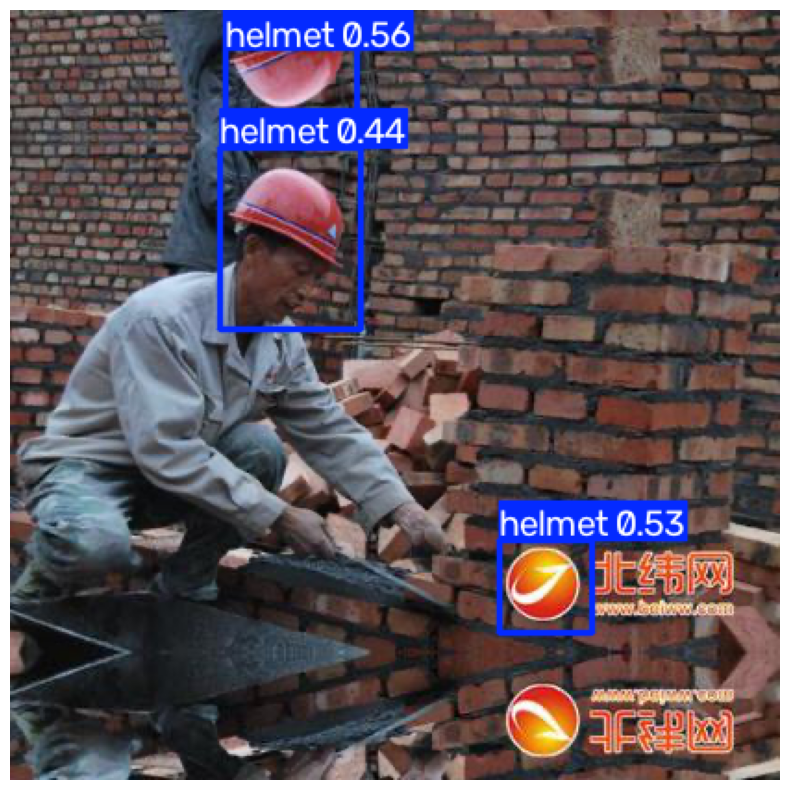

In [15]:
import matplotlib.pyplot as plt
import cv2
import os

# Dynamically get the annotated image directly from the results object
# results is a list of Results objects, and we processed only one image.
# results[0].plot() returns the annotated image as a numpy array.
img = results[0].plot() # This image is typically in BGR format from OpenCV

# Convert BGR to RGB for matplotlib display
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [17]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2067.7±905.3 MB/s, size: 245.7 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 99.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.2s/it 38.9s
                   all        500       2648      0.912      0.534       0.58      0.344
                helmet        455       1971      0.883      0.814      0.887      0.534
                  head         96        597      0.852      0.789      0.841      0.493
                person         16         80          1          0     0.0126     0.0048
Speed: 0.6ms preprocess, 62.9ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/detect/val
u